# Mini Project

Solutions from:   

Name: **Manoj Billur Nagendra Prasad**   
Matriculation Number: 2886261

Name: **Steffi Stephen**  
Matriculation Number: 4109600

**Goal:**

This Notebook explores the AIFB RDF knowledge graph and the accompanying machine learning datasets. The goal is to understand the structure of the RDF graph, analyze the prediction task, and identify important characteristics of the dataset before feature engineering.


The objectives of this notebook are to:

- Load and parse the AIFB RDF knowledge graph.
- Explore the structure and contents of the RDF graph.
- Analyze entities, predicates, literals, and RDF classes.
- Convert RDF URIs into human-readable names for easier interpretation.
- Explore the provided training, testing, and complete datasets.

This notebook uses the following input files:

| File | Description |
|------|-------------|
| `aifbfixed_complete.n3` | Complete RDF knowledge graph |
| `trainingSet.tsv` | Training instances and class labels |
| `testSet.tsv` | Test instances and class labels |
| `completeDataset.tsv` | Complete list of labelled instances |


This notebook does not generate intermediate files.

It produces:

- Exploratory statistics of the RDF graph.
- Human-readable RDF examples.
- Entity and predicate frequency analysis.
- RDF class distribution.
- Visualizations of important graph characteristics.

In [1]:
# =============================================================================
# Project Setup
# =============================================================================

from pathlib import Path
import sys

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

# Import project paths
from utils.paths import *

# Import helper functions
from utils.helper_functions import (
    get_entity_name,
    get_predicate_name,
    print_triple,
)

In [2]:
# =============================================================================
# Standard Library
# =============================================================================

from collections import Counter
import itertools

# =============================================================================
# Third-Party Libraries
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt

from rdflib import Graph

In [3]:
graph = Graph()

graph.parse(RDF_FILE, format="n3")

print("RDF graph loaded successfully.")

RDF graph loaded successfully.


# Raw RDF Data Analysis

In [4]:
print(f"Total number of RDF triples: {len(graph):,}")

Total number of RDF triples: 29,226


In [5]:
print("First 10 RDF triples:\n")

for i, (subject, predicate, obj) in enumerate(graph):
    print(f"Triple {i+1}")
    print(f"Subject   : {subject}")
    print(f"Predicate : {predicate}")
    print(f"Object    : {obj}")
    print("-" * 80)

    if i == 9:
        break

First 10 RDF triples:

Triple 1
Subject   : http://www.aifb.uni-karlsruhe.de/Personen/viewPersonOWL/id2043instance
Predicate : http://swrc.ontoware.org/ontology#publication
Object    : http://www.aifb.uni-karlsruhe.de/Publikationen/viewPublikationOWL/id369instance
--------------------------------------------------------------------------------
Triple 2
Subject   : http://www.aifb.uni-karlsruhe.de/Publikationen/viewPublikationOWL/id597instance
Predicate : http://swrc.ontoware.org/ontology#journal
Object    : International Journal of Human-Computer Studies
--------------------------------------------------------------------------------
Triple 3
Subject   : http://www.aifb.uni-karlsruhe.de/Publikationen/viewExternerAutorOWL/id313instance
Predicate : http://swrc.ontoware.org/ontology#publication
Object    : http://www.aifb.uni-karlsruhe.de/Publikationen/viewPublikationOWL/id472instance
--------------------------------------------------------------------------------
Triple 4
Subject   : htt

In [6]:
# why set because : it stores all unique nodes
nodes = set()

for subject, predicate, obj in graph:

    # adding the subjects information to the set: nodes
    nodes.add(subject)

    # Aadding the objects only if it is another RDF resource (URI) to the set: nodes
    if str(obj).startswith("http"):
        nodes.add(obj)

print(f"Total unique nodes (entities) (specially URLs): {len(nodes):,}")

Total unique nodes (entities) (specially URLs): 3,187


In [7]:
first_10_nodes = list(itertools.islice(nodes, 10))
print(first_10_nodes)

[rdflib.term.URIRef('http://www.aifb.uni-karlsruhe.de/Publikationen/viewExternerAutorOWL/id266instance'), rdflib.term.URIRef('http://www.aifb.uni-karlsruhe.de/Publikationen/viewExternerAutorOWL/id628instance'), rdflib.term.URIRef('http://www.aifb.uni-karlsruhe.de/Kooperationen/viewOrganizationOWL/id19instance'), rdflib.term.URIRef('http://www.aifb.uni-karlsruhe.de/Personen/viewPersonOWL/id3instance'), rdflib.term.URIRef('http://www.aifb.uni-karlsruhe.de/Publikationen/viewExternerAutorOWL/id601instance'), rdflib.term.Literal('http://www.aifb.uni-karlsruhe.de/Personen/Bilder/U1p2l3o4a5d2008', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#string')), rdflib.term.BNode('ub1bL597C18'), rdflib.term.URIRef('http://www.aifb.uni-karlsruhe.de/Personen/viewPersonOWL/id2147instance'), rdflib.term.URIRef('http://www.aifb.uni-karlsruhe.de/Projekte/viewProjektOWL/id59instance'), rdflib.term.URIRef('http://www.aifb.uni-karlsruhe.de/Publikationen/viewExternerAutorOWL/id75instance')]


In [8]:
# similary for predicate
predicates = set()

for _, predicate, _ in graph:
    predicates.add(predicate)

print(f"Total unique predicates: {len(predicates)}")

Total unique predicates: 47


In [9]:
url_objects_count = 0
literal_objects_count = 0

for _, _, obj in graph:

    if str(obj).startswith("http"):
        url_objects_count += 1
    else:
        literal_objects_count += 1

print(f"URL Objects Count     : {url_objects_count:,}")
print(f"Literal Objects Count : {literal_objects_count:,}")

URL Objects Count     : 20,858
Literal Objects Count : 8,368


In [10]:
# Store all unique literal objects
literal_objects = set()

for _, _, obj in graph:
    if not str(obj).startswith("http"):
        literal_objects.add(obj)

print(f"Total unique literal objects: {len(literal_objects):,}")

Total unique literal objects: 5,250


In [11]:
first_10_literal_objects = list(itertools.islice(literal_objects, 10))
print(first_10_literal_objects)

[rdflib.term.Literal('FPGA Implementation of Population based Ant Colony Optimization', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#string')), rdflib.term.Literal('Spinning the Semantic Web', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#string')), rdflib.term.BNode('ub1bL597C18'), rdflib.term.Literal('Proceedings of the 11th International World Wide Web Conference, WWW 2002, Honolulu, Hawaii, May 7-11, 2002', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#string')), rdflib.term.Literal('WM 2003', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#string')), rdflib.term.Literal('P-75', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#string')), rdflib.term.Literal('Rough operators on Boolean Algebras', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#string')), rdflib.term.Literal('Papers from 2004 AAAI Spring Symposium - Semantic Web Services', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLS

In [12]:
print("=" * 50)
print("AIFB Dataset Summary")
print("=" * 50)

print(f"URL objects            : {url_objects_count:,}")
print(f"Literal objects        : {literal_objects_count:,}")
print("-" * 40)
print(f"Total RDF triples      : {len(graph):,}")
print("-" * 40)
print(f"Unique entities (nodes) (specially URLs): {len(nodes):,}")
print(f"Unique predicates                       : {len(predicates)}")
print(f"Unique literal objects                  : {len(literal_objects)}")

AIFB Dataset Summary
URL objects            : 20,858
Literal objects        : 8,368
----------------------------------------
Total RDF triples      : 29,226
----------------------------------------
Unique entities (nodes) (specially URLs): 3,187
Unique predicates                       : 47
Unique literal objects                  : 5250


In [13]:
# Count how many times each node appears in the RDF graph
node_counter = Counter()

for subject, predicate, obj in graph:
    node_counter[str(subject)] += 1

    # Count object only if it is another RDF entity (URI)
    if str(obj).startswith("http"):
        node_counter[str(obj)] += 1

print("Top 20 most frequent nodes:\n")

for node, count in node_counter.most_common(20):
    print(f"{count:5d}   {node}")

Top 20 most frequent nodes:

 1247   http://swrc.ontoware.org/ontology#Publication
 1074   http://swrc.ontoware.org/ontology#Person
 1054   http://www.aifb.uni-karlsruhe.de/Forschungsgruppen/viewForschungsgruppeOWL/id3instance
  700   http://swrc.ontoware.org/ontology#InProceedings
  469   http://www.aifb.uni-karlsruhe.de/Personen/viewPersonOWL/id6instance
  461   http://www.aifb.uni-karlsruhe.de/Personen/viewPersonOWL/id57instance
  379   http://www.aifb.uni-karlsruhe.de/Personen/viewPersonOWL/id20instance
  355   http://www.aifb.uni-karlsruhe.de/Projekte/viewProjektOWL/id42instance
  320   http://www.aifb.uni-karlsruhe.de/Forschungsgebiete/viewForschungsgebietOWL/id79instance
  295   http://www.aifb.uni-karlsruhe.de/Forschungsgruppen/viewForschungsgruppeOWL/id1instance
  280   http://swrc.ontoware.org/ontology#ResearchTopic
  263   http://www.aifb.uni-karlsruhe.de/Projekte/viewProjektOWL/id49instance
  246   http://www.aifb.uni-karlsruhe.de/Personen/viewPersonOWL/id67instance
  215  

In [14]:
predicate_counter = Counter()

for _, predicate, _ in graph:
    predicate_counter[str(predicate)] += 1

print("Top 20 most frequent predicates:\n")

for predicate, count in predicate_counter.most_common(20):
    print(f"{count:5d}   {predicate}")
    

Top 20 most frequent predicates:

 4163   http://swrc.ontoware.org/ontology#publication
 4124   http://www.w3.org/1999/02/22-rdf-syntax-ns#type
 3986   http://swrc.ontoware.org/ontology#author
 2477   http://swrc.ontoware.org/ontology#isAbout
 1302   http://swrc.ontoware.org/ontology#name
 1227   http://swrc.ontoware.org/ontology#year
 1227   http://swrc.ontoware.org/ontology#title
 1217   http://swrc.ontoware.org/ontology#publishes
  952   http://swrc.ontoware.org/ontology#projectInfo
  952   http://swrc.ontoware.org/ontology#hasProject
  765   http://swrc.ontoware.org/ontology#booktitle
  759   http://swrc.ontoware.org/ontology#month
  571   http://swrc.ontoware.org/ontology#isWorkedOnBy
  548   http://swrc.ontoware.org/ontology#pages
  534   http://swrc.ontoware.org/ontology#abstract
  357   http://swrc.ontoware.org/ontology#dealtWithIn
  339   http://swrc.ontoware.org/ontology#member
  311   http://swrc.ontoware.org/ontology#volume
  298   http://swrc.ontoware.org/ontology#series
 

In [15]:
# Count how many times each literal object appears
literal_counter = Counter()

for _, _, obj in graph:
    if not str(obj).startswith("http"):
        literal_counter[str(obj)] += 1

print("Top 20 most frequent literal objects:\n")

for literal, count in literal_counter.most_common(20):
    print(f"{count:5d}   {literal}")

Top 20 most frequent literal objects:

  237   2005
  205   
  189   2006
  178   2004
  168   2003
  145   2002
   89   September
   84   May
   82   November
   77   July
   75   October
   69   August
   66   June
   58   2001
   56   December
   55   LNCS
   53   2000
   47   January
   41   March
   38   April


# Human-readable Conversion

In [16]:
# But to see all the different patterns of the URI, we Collect all the URI prefixes used in the dataset (specially in nodes)

uri_patterns = set()

for node in nodes:
    uri = str(node)

    if "#" in uri:
        uri_patterns.add(uri.split("#")[0] + "#")
    else:
        parts = uri.split("/")

        if len(parts) >= 5:
            uri_patterns.add("/".join(parts[:5]))

print("URI Patterns:\n")

for pattern in sorted(uri_patterns):
    print(pattern)

URI Patterns:

file:///D:/00000%20Coding%20Restart%202025
http://arti.vub.ac.be/~steels/
http://balboa2.wiwi.uni-frankfurt.de/projekte/premium
http://cis.cs.tu-berlin.de/~aloeser/vitae.htm
http://db.cwi.nl/personen/publiek
http://ectrl.itc.it/home/home_people
http://homepage.uibk.ac.at/~c703261/
http://kmi.open.ac.uk/projects/dotkom
http://knowledgeweb.semanticweb.org/semanticportal/home.jsp?_origin=%2Fhome.jsp&instance=Alain+Giboin&ontology=Person+Ontology&content=instance.jsp&instance_set=kweb&var_name=instance
http://logic.aifb.uni-karlsruhe.de/wiki/OntoLoRe
http://lwi2.wiwi.uni-frankfurt.de/mitarbeiter/gruene
http://maya.cs.depaul.edu/~mobasher/
http://members.xoom.virgilio.it/fmricci/
http://nm.wu-wien.ac.at/people/Simon.html
http://ontoware.org/projects/swrc
http://page.mi.fu-berlin.de/~mochol/
http://personal.sirma.bg/AtanasKiryakov/cv.htm
http://potato.cs.man.ac.uk/seanb/
http://smi-web.stanford.edu/auslese/smi-web
http://smi-web.stanford.edu/people/noy
http://smi-web.stanford.

In [17]:
# Collect all unique URI patterns used by predicates

predicate_patterns = set()

for predicate in predicates:
    predicate = str(predicate)

    if "#" in predicate:
        predicate_patterns.add(predicate.split("#")[0] + "#")
    else:
        parts = predicate.rstrip("/").split("/")

        if len(parts) >= 5:
            predicate_patterns.add("/".join(parts[:5]))

print("Predicate URI Patterns:\n")

for pattern in sorted(predicate_patterns):
    print(pattern)

Predicate URI Patterns:

http://swrc.ontoware.org/ontology#
http://www.aifb.uni-karlsruhe.de/WBS/dvr
http://www.w3.org/1999/02/22-rdf-syntax-ns#
http://www.w3.org/2000/01/rdf-schema#
http://www.w3.org/2002/07/owl#


In [18]:
# Collect all unique URI patterns used by predicates

predicate_patterns = set()

for predicate in predicates:
    predicate = str(predicate)

    if "#" in predicate:
        predicate_patterns.add(predicate.split("#")[0] + "#")
    else:
        parts = predicate.rstrip("/").split("/")

        if len(parts) >= 5:
            predicate_patterns.add("/".join(parts[:5]))

print("Predicate URI Patterns:\n")

for pattern in sorted(predicate_patterns):
    print(pattern)

Predicate URI Patterns:

http://swrc.ontoware.org/ontology#
http://www.aifb.uni-karlsruhe.de/WBS/dvr
http://www.w3.org/1999/02/22-rdf-syntax-ns#
http://www.w3.org/2000/01/rdf-schema#
http://www.w3.org/2002/07/owl#


In [19]:
print("First 10 Human-Readable RDF Triples\n")

for i, (subject, predicate, obj) in enumerate(graph):

    print(f"Triple {i+1}")

    print_triple(subject, predicate, obj)

    if i == 9:
        break

First 10 Human-Readable RDF Triples

Triple 1
Subject   : Personen(id2043instance)
Predicate : publication
Object    : Publikationen(id369instance)
--------------------------------------------------------------------------------
Triple 2
Subject   : Publikationen(id597instance)
Predicate : journal
Object    : International Journal of Human-Computer Studies
--------------------------------------------------------------------------------
Triple 3
Subject   : Publikationen(id313instance)
Predicate : publication
Object    : Publikationen(id472instance)
--------------------------------------------------------------------------------
Triple 4
Subject   : Publikationen(id786instance)
Predicate : type
Object    : Article
--------------------------------------------------------------------------------
Triple 5
Subject   : Publikationen(id159instance)
Predicate : isAbout
Object    : Forschungsgebiete(id106instance)
--------------------------------------------------------------------------------


In [20]:
node_counter = Counter()

for subject, predicate, obj in graph:

    node_counter[get_entity_name(subject)] += 1

    if str(obj).startswith("http"):
        node_counter[get_entity_name(obj)] += 1

print("Top 20 most frequent nodes:\n")

for node, count in node_counter.most_common(20):
    print(f"{count:5d}   {node}")

Top 20 most frequent nodes:

 1247   Publication
 1074   Person
 1054   Forschungsgruppen(id3instance)
  700   InProceedings
  469   Personen(id6instance)
  461   Personen(id57instance)
  379   Personen(id20instance)
  355   Projekte(id42instance)
  320   Forschungsgebiete(id79instance)
  295   Forschungsgruppen(id1instance)
  280   ResearchTopic
  263   Projekte(id49instance)
  246   Personen(id67instance)
  215   Projekte(id43instance)
  212   Forschungsgruppen(id2instance)
  195   Projekte(id50instance)
  174   TechnicalReport
  171   Personen(id2084instance)
  170   Personen(id50instance)
  169   Article


In [21]:
predicate_counter = Counter()

for _, predicate, _ in graph:
    predicate_counter[get_predicate_name(predicate)] += 1

print("Top 20 Most Frequent Predicates\n")

for predicate, count in predicate_counter.most_common(20):
    print(f"{count:5d}   {predicate}")

Top 20 Most Frequent Predicates

 4174   type
 4163   publication
 3986   author
 2477   isAbout
 1302   name
 1227   year
 1227   title
 1217   publishes
  952   projectInfo
  952   hasProject
  765   booktitle
  759   month
  571   isWorkedOnBy
  548   pages
  534   abstract
  357   dealtWithIn
  339   member
  311   volume
  298   series
  239   homepage


In [22]:
## converting into the dataframe
edge_type_df = (
    pd.DataFrame(
        predicate_counter.items(),
        columns=["Edge Type", "Count"]
    )
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

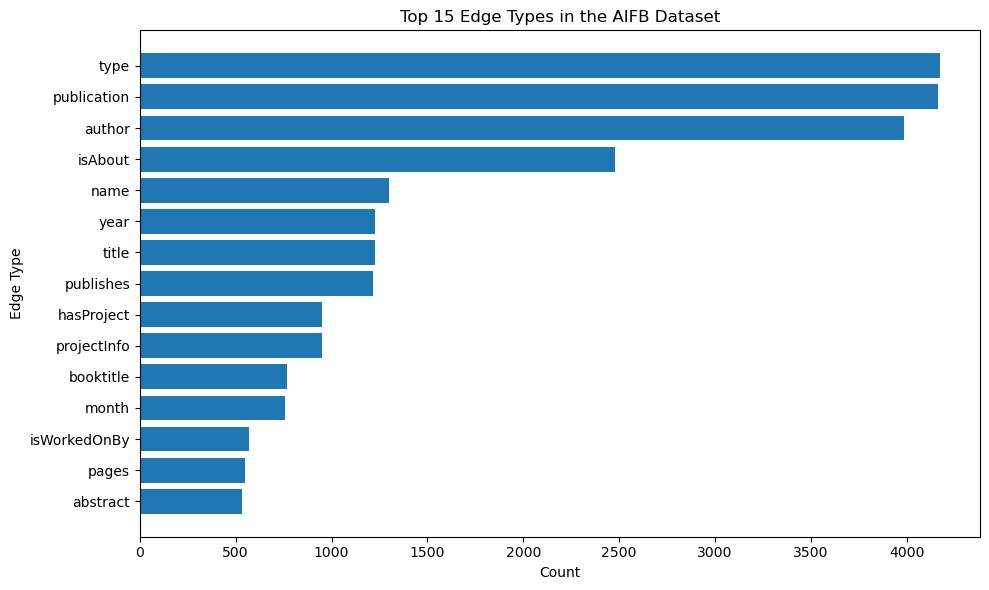

In [41]:
top_edge_types = edge_type_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(top_edge_types["Edge Type"],
         top_edge_types["Count"])

plt.xlabel("Count")
plt.ylabel("Edge Type")
plt.title("Top 15 Edge Types in the AIFB Dataset")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(FIGURES_DIR / "top_edge_types.png", dpi=300)

plt.show()

The above will answer the question: What are the most frequent edge types?, edge is nothing but predicate

### Exploring type triplets

To answer for the question: What are the most frequent node types?

In [24]:
type_triples = []

for subject, predicate, obj in graph:

    if get_predicate_name(predicate) == "type":
        type_triples.append((subject, predicate, obj))

print(f"Total rdf:type triples: {len(type_triples)}")

Total rdf:type triples: 4174


In [25]:
print("First 10 rdf:type triples\n")

for i, (subject, predicate, obj) in enumerate(type_triples):

    print(f"Type Triple {i+1}")

    print_triple(subject, predicate, obj)

    if i == 9:
        break

First 10 rdf:type triples

Type Triple 1
Subject   : Publikationen(id786instance)
Predicate : type
Object    : Article
--------------------------------------------------------------------------------
Type Triple 2
Subject   : Projekte(id44instance)
Predicate : type
Object    : Project
--------------------------------------------------------------------------------
Type Triple 3
Subject   : Forschungsgebiete(id48instance)
Predicate : type
Object    : ResearchTopic
--------------------------------------------------------------------------------
Type Triple 4
Subject   : Publikationen(id1285instance)
Predicate : type
Object    : InCollection
--------------------------------------------------------------------------------
Type Triple 5
Subject   : Personen(id2096instance)
Predicate : type
Object    : PhDStudent
--------------------------------------------------------------------------------
Type Triple 6
Subject   : Publikationen(id610instance)
Predicate : type
Object    : Publication
----

In [26]:
# Count the number of entities belonging to each RDF class

node_type_counter = Counter()

for subject, predicate, obj in type_triples:
    node_type_counter[get_entity_name(obj)] += 1

print("Node Type Distribution\n")

for node_type, count in node_type_counter.most_common():
    print(f"{count:5d}   {node_type}")

Node Type Distribution

 1222   Publication
 1045   Person
  687   InProceedings
  169   TechnicalReport
  161   Article
  152   Restriction
  146   ResearchTopic
   87   InCollection
   78   Project
   65   PhDStudent
   55   Class
   51   Misc
   49   Proceedings
   42   ObjectProperty
   31   DatatypeProperty
   28   Organization
   23   Book
   12   Knowledge Web Deliverable
   10   OntoWeb deliverable
    8   SEKT Deliverable
    6   Lecturer
    6   On-To-Knowledge deliverable
    6   Undergraduate
    5   FullProfessor
    5   ResearchGroup
    4   SEKT informal deliverable
    3   AssistantProfessor
    3   TechnicalStaff
    2   Graduate
    2   SEKT formal deliverable
    2   aceMedia External Deliverable
    1   Ontology
    1   Deliverable
    1   Datatype
    1   SEKT Formal Deliverable
    1   SEKT deliverable
    1   Manager
    1   On-To-Knowledge technical fact sheet
    1   KWeb Deliverable
    1   aceMedia Internal Deliverable


In [27]:
## conerting to the dataframe
node_type_df = (
    pd.DataFrame(
        node_type_counter.items(),
        columns=["Node Type", "Count"]
    )
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

In [29]:
print(f"Total unique node types: {len(node_type_df)}")

Total unique node types: 40


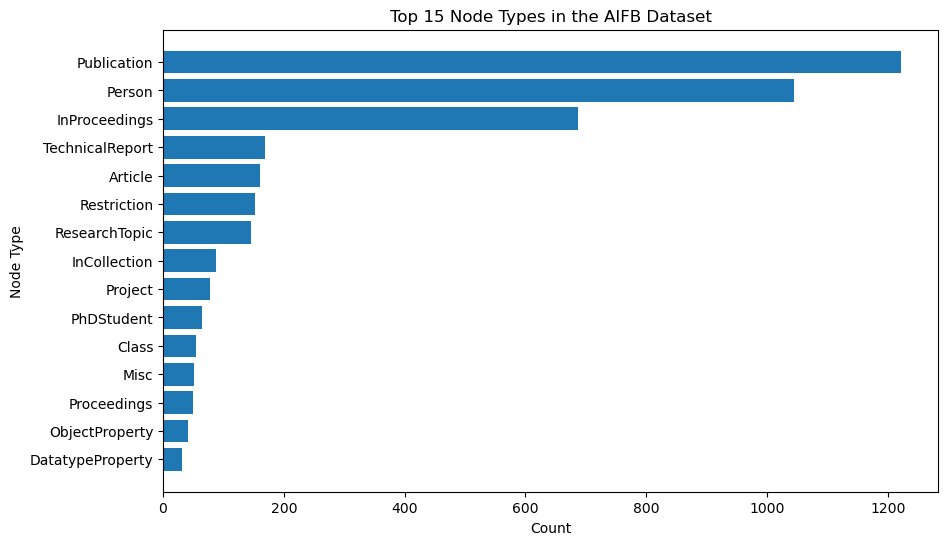

In [42]:
top_node_types = node_type_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(top_node_types["Node Type"], top_node_types["Count"])

plt.xlabel("Count")
plt.ylabel("Node Type")
plt.title("Top 15 Node Types in the AIFB Dataset")

plt.gca().invert_yaxis()

plt.savefig(FIGURES_DIR / "node_type_distribution.png", dpi=300)

plt.show()

In [30]:
# Collect example entities for each node type

from collections import defaultdict

node_type_examples = defaultdict(list)

for subject, predicate, obj in type_triples:

    node_type = get_entity_name(obj)

    if len(node_type_examples[node_type]) < 5:
        node_type_examples[node_type].append(get_entity_name(subject))

In [31]:
important_types = [
    "Person",
    "Publication",
    "Project",
    "ResearchGroup",
    "ResearchTopic",
    "Organization"
]

for node_type in important_types:

    print("=" * 60)
    print(node_type)

    if node_type in node_type_examples:
        for entity in node_type_examples[node_type]:
            print("  •", entity)
    else:
        print("  No examples found.")

Person
  • Publikationen(id33instance)
  • Publikationen(id733instance)
  • Publikationen(id224instance)
  • Publikationen(id78instance)
  • Publikationen(id741instance)
Publication
  • Publikationen(id610instance)
  • Publikationen(id218instance)
  • Publikationen(id52instance)
  • Publikationen(id91instance)
  • Publikationen(id0instance)
Project
  • Projekte(id44instance)
  • Projekte(id29instance)
  • Projekte(id31instance)
  • Projekte(id12instance)
  • Projekte(id71instance)
ResearchGroup
  • Forschungsgruppen(id2instance)
  • Forschungsgruppen(id4instance)
  • Forschungsgruppen(id1instance)
  • Forschungsgruppen(id3instance)
  • Forschungsgruppen(id5instance)
ResearchTopic
  • Forschungsgebiete(id48instance)
  • Forschungsgebiete(id154instance)
  • Forschungsgebiete(id32instance)
  • Forschungsgebiete(id135instance)
  • Forschungsgebiete(id64instance)
Organization
  • Kooperationen(id6instance)
  • Kooperationen(id4instance)
  • Kooperationen(id16instance)
  • Kooperationen(id25

# Understand the Machine Learning Dataset (.tsv files)

## trainingSet.tsv

In [32]:
train_df = pd.read_csv(TRAIN_FILE, sep="\t")

In [33]:
train_df.head()

,person,id,label_affiliation
0,http://www.aifb.uni-karlsruhe.de/Personen/view...,2.0,http://www.aifb.uni-karlsruhe.de/Forschungsgru...
1,http://www.aifb.uni-karlsruhe.de/Personen/view...,3.0,http://www.aifb.uni-karlsruhe.de/Forschungsgru...
2,http://www.aifb.uni-karlsruhe.de/Personen/view...,4.0,http://www.aifb.uni-karlsruhe.de/Forschungsgru...
3,http://www.aifb.uni-karlsruhe.de/Personen/view...,5.0,http://www.aifb.uni-karlsruhe.de/Forschungsgru...
4,http://www.aifb.uni-karlsruhe.de/Personen/view...,6.0,http://www.aifb.uni-karlsruhe.de/Forschungsgru...


The id column is simply an internal identifier assigned by the dataset creators.It is not a feature. It carries no semantic information.

In [34]:
print(f"Rows    : {train_df.shape[0]}")
print(f"Columns : {train_df.shape[1]}")

Rows    : 140
Columns : 3


In [35]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   person             140 non-null    object 
 1   id                 140 non-null    float64
 2   label_affiliation  140 non-null    object 
dtypes: float64(1), object(2)
memory usage: 3.4+ KB


In [36]:
train_df.isnull().sum()

person               0
id                   0
label_affiliation    0
dtype: int64

In [37]:
print("Duplicate Rows:", train_df.duplicated().sum())

Duplicate Rows: 0


In [38]:
# Unique Values per Column
for column in train_df.columns:
    print("="*50)
    print(column)
    print(f"Unique values: {train_df[column].nunique()}")

person
Unique values: 140
id
Unique values: 140
label_affiliation
Unique values: 4


In [39]:
print("Unique Values in the label_affiliation are:\n")

for label in train_df["label_affiliation"].unique():
    print(get_entity_name(label))

Unique Values in the label_affiliation are:

Forschungsgruppen(id1instance)
Forschungsgruppen(id3instance)
Forschungsgruppen(id2instance)
Forschungsgruppen(id4instance)


In [40]:
label_counts = train_df["label_affiliation"].apply(get_entity_name).value_counts()

label_counts

label_affiliation
Forschungsgruppen(id1instance)    58
Forschungsgruppen(id3instance)    48
Forschungsgruppen(id2instance)    22
Forschungsgruppen(id4instance)    12
Name: count, dtype: int64

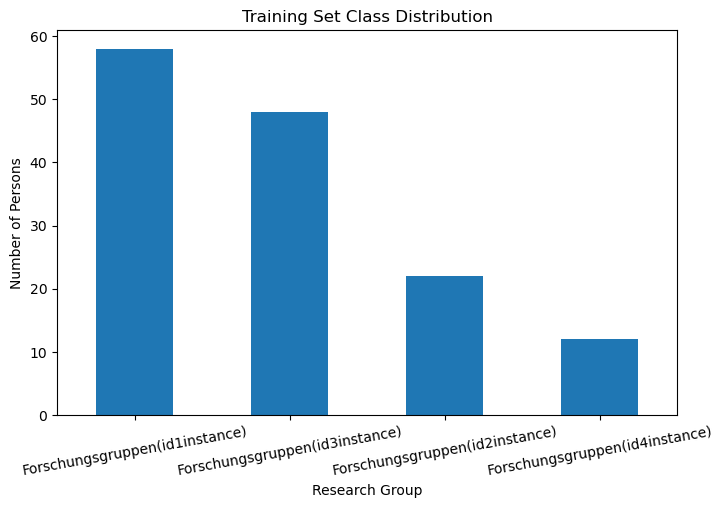

In [43]:
plt.figure(figsize=(8,5))

label_counts.plot(kind="bar")

plt.title("Training Set Class Distribution")
plt.xlabel("Research Group")
plt.ylabel("Number of Persons")

plt.xticks(rotation=10)

plt.savefig(FIGURES_DIR / "Training_Set_Class_Distribution.png", dpi=300)

plt.show()

## testSet.tsv

In [44]:
test_df = pd.read_csv(TEST_FILE, sep="\t")

In [45]:
test_df.head()

,person,id,label_affiliation
0,http://www.aifb.uni-karlsruhe.de/Personen/view...,1.0,http://www.aifb.uni-karlsruhe.de/Forschungsgru...
1,http://www.aifb.uni-karlsruhe.de/Personen/view...,12.0,http://www.aifb.uni-karlsruhe.de/Forschungsgru...
2,http://www.aifb.uni-karlsruhe.de/Personen/view...,14.0,http://www.aifb.uni-karlsruhe.de/Forschungsgru...
3,http://www.aifb.uni-karlsruhe.de/Personen/view...,16.0,http://www.aifb.uni-karlsruhe.de/Forschungsgru...
4,http://www.aifb.uni-karlsruhe.de/Personen/view...,25.0,http://www.aifb.uni-karlsruhe.de/Forschungsgru...


In [46]:
print(f"Rows    : {test_df.shape[0]}")
print(f"Columns : {test_df.shape[1]}")

Rows    : 36
Columns : 3


In [47]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   person             36 non-null     object 
 1   id                 36 non-null     float64
 2   label_affiliation  36 non-null     object 
dtypes: float64(1), object(2)
memory usage: 996.0+ bytes


In [48]:
print(test_df.isnull().sum())

person               0
id                   0
label_affiliation    0
dtype: int64


In [49]:
print("Duplicate Rows:", test_df.duplicated().sum())

Duplicate Rows: 0


In [50]:
# Unique Values per Column
for column in test_df.columns:
    print("="*50)
    print(column)
    print(f"Unique values: {test_df[column].nunique()}")

person
Unique values: 36
id
Unique values: 36
label_affiliation
Unique values: 4


In [51]:
print("Unique Values in the label_affiliation are:\n")

for label in test_df["label_affiliation"].unique():
    print(get_entity_name(label))

Unique Values in the label_affiliation are:

Forschungsgruppen(id1instance)
Forschungsgruppen(id3instance)
Forschungsgruppen(id2instance)
Forschungsgruppen(id4instance)


In [52]:
test_label_counts = (
    test_df["label_affiliation"]
    .apply(get_entity_name)
    .value_counts()
)

print(test_label_counts)

label_affiliation
Forschungsgruppen(id1instance)    15
Forschungsgruppen(id3instance)    12
Forschungsgruppen(id2instance)     6
Forschungsgruppen(id4instance)     3
Name: count, dtype: int64


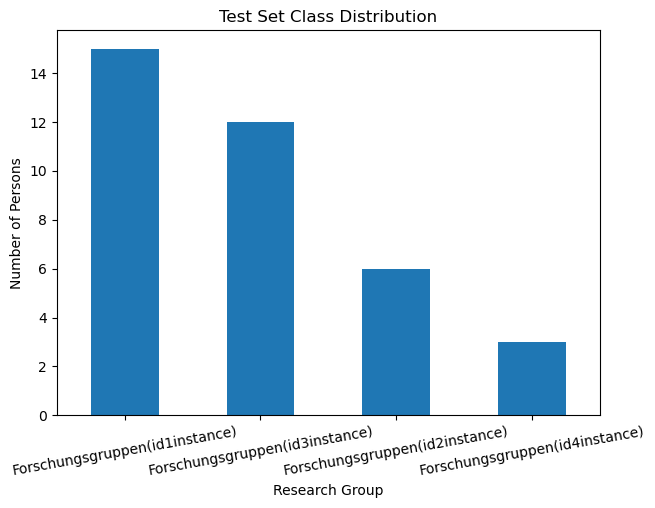

In [54]:
plt.figure(figsize=(7,5))

test_label_counts.plot(kind="bar")

plt.title("Test Set Class Distribution")
plt.xlabel("Research Group")
plt.ylabel("Number of Persons")

plt.xticks(rotation=10)

plt.savefig(FIGURES_DIR / "Test_Set_Class_Distribution.png", dpi=300)

plt.show()

## traning vs test set

In [55]:
comparison_df = pd.DataFrame({
    "Dataset": ["Training", "Test"],
    "Samples": [len(train_df), len(test_df)],
    "Classes": [
        train_df["label_affiliation"].nunique(),
        test_df["label_affiliation"].nunique()
    ]
})

comparison_df

,Dataset,Samples,Classes
0,Training,140,4
1,Test,36,4


In [56]:
train_persons = set(train_df["person"])
test_persons = set(test_df["person"])

overlap = train_persons.intersection(test_persons)

print(f"Number of overlapping persons: {len(overlap)}")

Number of overlapping persons: 0


## completeDataset.tsv

In [58]:
complete_df = pd.read_csv(COMPLETE_DATASET_FILE, sep="\t")

In [59]:
complete_df.head()

,id,person,label_affiliation
0,1,http://www.aifb.uni-karlsruhe.de/Personen/view...,http://www.aifb.uni-karlsruhe.de/Forschungsgru...
1,2,http://www.aifb.uni-karlsruhe.de/Personen/view...,http://www.aifb.uni-karlsruhe.de/Forschungsgru...
2,3,http://www.aifb.uni-karlsruhe.de/Personen/view...,http://www.aifb.uni-karlsruhe.de/Forschungsgru...
3,4,http://www.aifb.uni-karlsruhe.de/Personen/view...,http://www.aifb.uni-karlsruhe.de/Forschungsgru...
4,5,http://www.aifb.uni-karlsruhe.de/Personen/view...,http://www.aifb.uni-karlsruhe.de/Forschungsgru...


In [60]:
print(f"Rows    : {complete_df.shape[0]}")
print(f"Columns : {complete_df.shape[1]}")

print("\nColumn Names:")
print(complete_df.columns.tolist())

print("\nMissing Values:")
print(complete_df.isnull().sum())

print("\nDuplicate Rows:", complete_df.duplicated().sum())

print("\nUnique Persons:", complete_df["person"].nunique())

print("\nUnique Labels:", complete_df["label_affiliation"].nunique())

Rows    : 176
Columns : 3

Column Names:
['id', 'person', 'label_affiliation']

Missing Values:
id                   0
person               0
label_affiliation    0
dtype: int64

Duplicate Rows: 0

Unique Persons: 176

Unique Labels: 4
